# Food.com Dataset - Priprema podataka
Cilj ovog notebook-a je priprema podataka za kasnije klasterovanje i klasifikaciju recepata.
Koraci uključuju:
- čišćenje recepata i review podataka
- agregaciju statistika po receptu
- one-hot encoding sastojaka
- spajanje nutritivnih i ingredient feature-a

## Učitavanje potrebnih biblioteka

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import ast
from scipy.stats import ttest_ind
from sklearn.preprocessing import MultiLabelBinarizer
import pickle
from sklearn.feature_selection import VarianceThreshold

## Učitavanje podataka

In [5]:
df_recipes = pd.read_csv("RAW_recipes.csv")
df_interactions = pd.read_csv("RAW_interactions.csv")

Podaci o receptima

In [6]:
df_recipes.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [7]:
df_recipes.shape

(231637, 12)

In [8]:
df_recipes.dtypes

name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object

In [9]:
feature_names_recipes = df_recipes.columns[:]
feature_names_recipes

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='object')

In [10]:
df_recipes.isna().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [11]:
df_recipes = df_recipes.dropna(subset=["name"])

In [12]:
df_recipes[['minutes', 'n_steps', 'n_ingredients']].describe()

,minutes,n_steps,n_ingredients
count,2.316360e+05,231636.000000,231636.000000
mean,9.398587e+03,9.765516,9.051149
std,4.461973e+06,5.995136,3.734803
min,0.000000e+00,0.000000,1.000000
25%,2.000000e+01,6.000000,6.000000
50%,4.000000e+01,9.000000,9.000000
75%,6.500000e+01,12.000000,11.000000
max,2.147484e+09,145.000000,43.000000


In [13]:
df_recipes[['minutes', 'n_steps', 'n_ingredients']].skew()

minutes          481.285463
n_steps            2.033774
n_ingredients      0.768052
dtype: float64

In [14]:
df_recipes[['minutes', 'n_steps', 'n_ingredients']].kurt()

minutes          231635.797999
n_steps              10.685584
n_ingredients         1.175765
dtype: float64

In [15]:
df = df_interactions.merge(
    df_recipes,
    left_on="recipe_id",
    right_on="id"
)
df["has_description"] = df["description"].isna().astype(int)
df.groupby("has_description")["rating"].mean()

has_description
0    4.411980
1    4.365717
Name: rating, dtype: float64

In [16]:
df_recipes = df_recipes.fillna("")

In [17]:
df_recipes.isna().sum()

name              0
id                0
minutes           0
contributor_id    0
submitted         0
tags              0
nutrition         0
n_steps           0
steps             0
description       0
ingredients       0
n_ingredients     0
dtype: int64

In [18]:
df_recipes["id"].is_unique

True

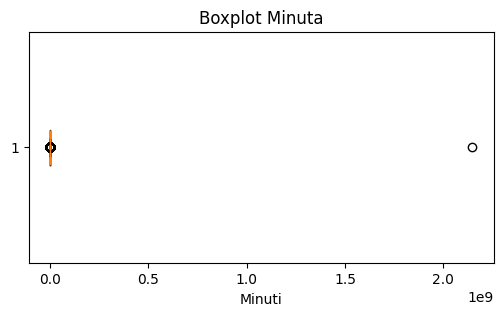

In [19]:
plt.figure(figsize=(6,3))
plt.boxplot(df_recipes["minutes"], vert=False)
plt.title("Boxplot Minuta")
plt.xlabel("Minuti")
plt.show()

In [20]:
df_recipes[df_recipes["minutes"] > 500]["name"].count()

np.int64(4338)

In [21]:
upper_limit = 1440
df_recipes = df_recipes[df_recipes['minutes'] <= upper_limit]

In [22]:
df_recipes["minutes"].describe()

count    229636.000000
mean         64.731314
std         100.600835
min           0.000000
25%          20.000000
50%          40.000000
75%          65.000000
max        1440.000000
Name: minutes, dtype: float64

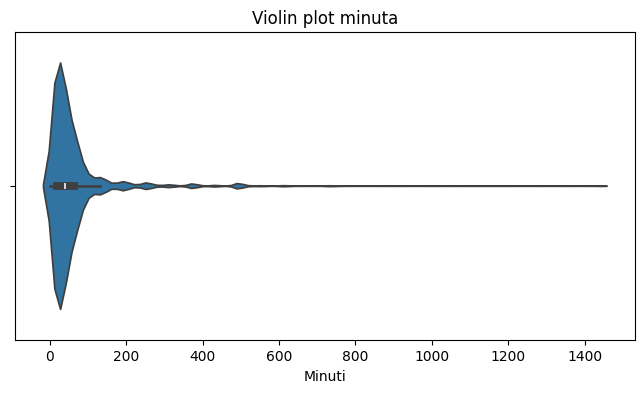

In [23]:
plt.figure(figsize=(8,4))
sns.violinplot(x=df_recipes["minutes"])
plt.title("Violin plot minuta")
plt.xlabel("Minuti")
plt.show()


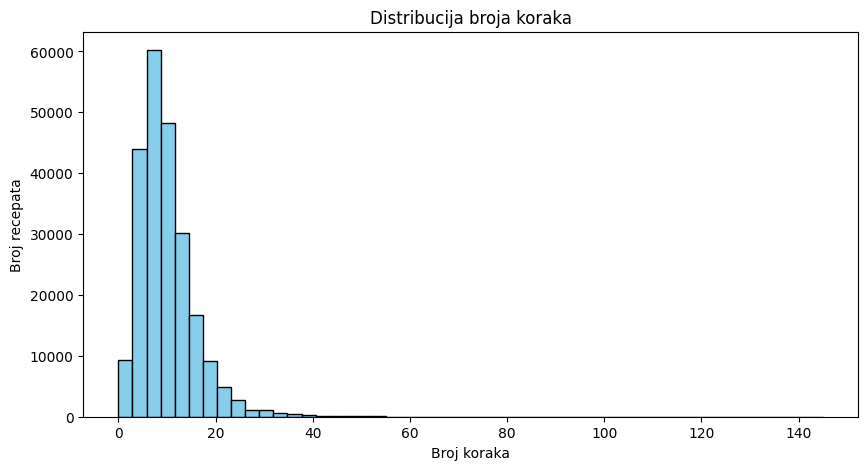

In [24]:
plt.figure(figsize=(10,5))
plt.hist(df_recipes["n_steps"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribucija broja koraka")
plt.xlabel("Broj koraka")
plt.ylabel("Broj recepata")
plt.show()

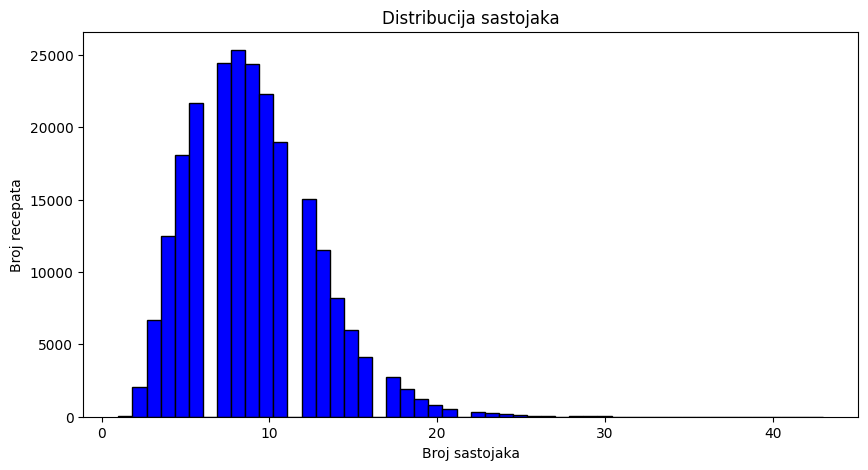

In [25]:
plt.figure(figsize=(10,5))
plt.hist(df_recipes["n_ingredients"], bins=50, color="blue", edgecolor="black")
plt.title("Distribucija sastojaka")
plt.xlabel("Broj sastojaka")
plt.ylabel("Broj recepata")
plt.show()

In [26]:
df_recipes["submitted"] = pd.to_datetime(df_recipes["submitted"], errors="coerce")

In [27]:
df_recipes["submitted"].describe()

count                           229636
mean     2006-11-15 06:10:32.848507904
min                1999-08-06 00:00:00
25%                2004-09-17 00:00:00
50%                2007-01-25 00:00:00
75%                2008-10-30 00:00:00
max                2018-12-04 00:00:00
Name: submitted, dtype: object

In [28]:
df_recipes["n_tags"]=df_recipes["tags"].apply(len)

In [29]:
df_recipes["n_tags"].describe()

count    229636.000000
mean        255.414748
std         101.650453
min           4.000000
25%         180.000000
50%         244.000000
75%         318.000000
max        1029.000000
Name: n_tags, dtype: float64

In [30]:
df_recipes["nutrition_parsed"] = df_recipes["nutrition"].apply(lambda x: ast.literal_eval(x))

df_recipes["calories"] = df_recipes["nutrition_parsed"].apply(lambda x: x[0])
df_recipes["fat"] = df_recipes["nutrition_parsed"].apply(lambda x: x[1])
df_recipes["sugar"] = df_recipes["nutrition_parsed"].apply(lambda x: x[2])
df_recipes["sodium"] = df_recipes["nutrition_parsed"].apply(lambda x: x[3])
df_recipes["protein"] = df_recipes["nutrition_parsed"].apply(lambda x: x[4])
df_recipes["saturated fat"] = df_recipes["nutrition_parsed"].apply(lambda x: x[5])
df_recipes["carbohydrates"] = df_recipes["nutrition_parsed"].apply(lambda x: x[6])

df_recipes = df_recipes.drop(columns = 'nutrition_parsed')
df_recipes = df_recipes.drop(columns = "nutrition")

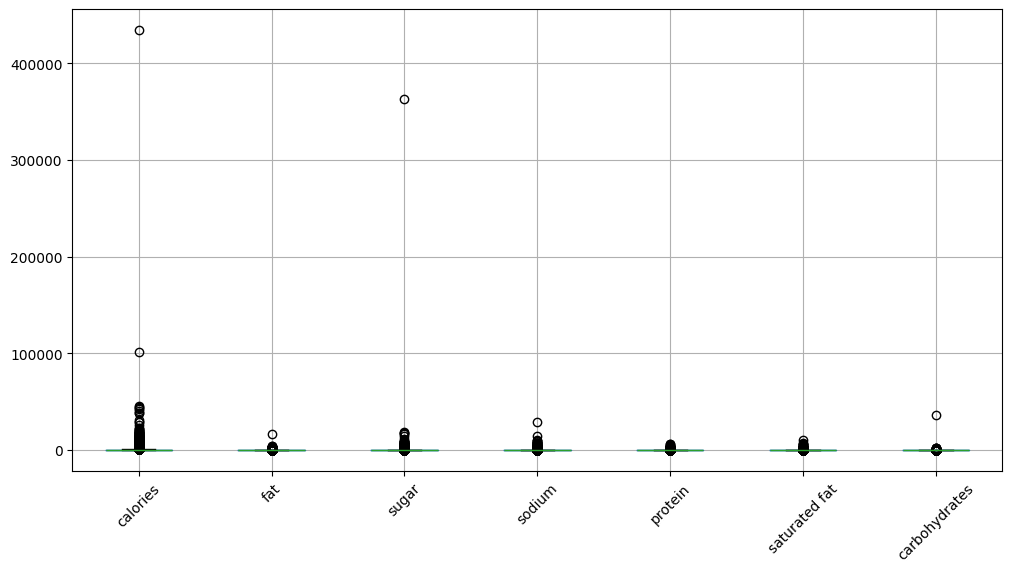

In [31]:
cols = ["calories", "fat", "sugar", "sodium",
        "protein", "saturated fat", "carbohydrates"]
plt.figure(figsize=(12,6))
df_recipes[cols].boxplot()
plt.xticks(rotation=45)
plt.show()

In [32]:
df_recipes[df_recipes["sugar"] > 100000]["id"].count()

np.int64(1)

In [33]:
df_recipes[df_recipes["calories"] > 100000]["id"].count()

np.int64(2)

In [34]:
df_recipes = df_recipes[df_recipes["calories"] < 100000]

Dve ekstremne vrednosti (>100 000 kcal) su izbačene, jer je tolika količina kalorija praktično nemoguća za jedan recept.

In [35]:
df_recipes[df_recipes["sugar"] > 100000]["id"].count()

np.int64(0)

Podaci o interakcijama

In [36]:
df_interactions.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [37]:
feature_names_interactions = df_interactions.columns[:]
feature_names_interactions

Index(['user_id', 'recipe_id', 'date', 'rating', 'review'], dtype='object')

In [38]:
df_interactions.dtypes

user_id       int64
recipe_id     int64
date         object
rating        int64
review       object
dtype: object

In [39]:
df_interactions.isna().sum()

user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64

In [40]:
df_interactions = df_interactions.fillna("")

In [41]:
df_interactions[['rating']].skew()

rating   -2.571001
dtype: float64

In [42]:
df_interactions[['rating']].kurt()

rating    5.805624
dtype: float64

In [43]:
df_interactions["rating"].describe()

count    1.132367e+06
mean     4.411016e+00
std      1.264752e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [44]:
df_interactions["rating"].value_counts()

rating
5    816364
4    187360
0     60847
3     40855
2     14123
1     12818
Name: count, dtype: int64

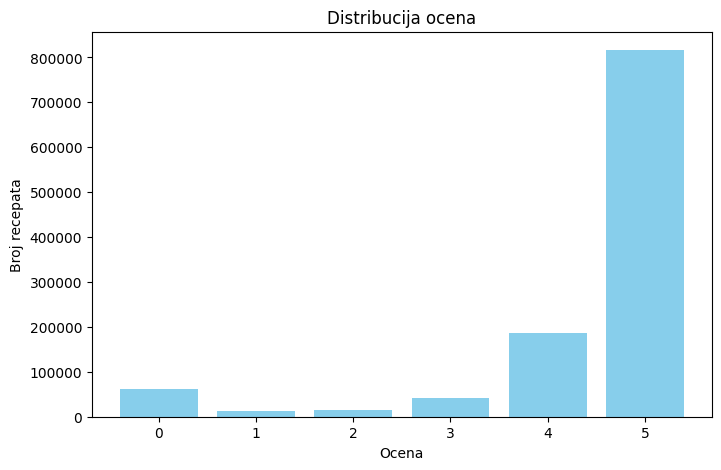

In [45]:
rating_counts = df_interactions["rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values, color='skyblue')
plt.xlabel("Ocena")
plt.ylabel("Broj recepata")
plt.title("Distribucija ocena")
plt.xticks(rating_counts.index) 
plt.show()

In [46]:
df_interactions[(df_interactions["rating"] == 0) & (df_interactions["review"].str.strip() == "")]

,user_id,recipe_id,date,rating,review


0 je validna ocena

In [47]:
matched = df_recipes["id"].isin(df_interactions["recipe_id"]).sum()
total_recipes = len(df_recipes)
print(f"{matched} od {total_recipes} recepata ima ocenu")

ratings_without_recipe = (~df_interactions["recipe_id"].isin(df_recipes["id"])).sum()
print(f"{ratings_without_recipe} ocena se odnosi na nepoznate recepte")

229634 od 229634 recepata ima ocenu
8226 ocena se odnosi na nepoznate recepte


In [48]:
df_unmatched_ratings = df_interactions[~df_interactions["recipe_id"].isin(df_recipes["id"])]

In [49]:
df_unmatched_ratings.head()

,user_id,recipe_id,date,rating,review
2266,424680,384106,2009-09-11,5,Made this bread using part of another recipe o...
2267,439759,384106,2009-10-28,4,"Really yummy, but got kind of chewy after a da..."
2558,160974,239666,2007-08-09,5,"My bread turned out exactly as you described, ..."
2559,130819,239666,2007-08-17,5,We enjoy those specialty loaves of bread that ...
2560,1858347,239666,2014-01-27,0,"This was amazing, everyone in my family loved it."


In [50]:
matched_users = df_unmatched_ratings["user_id"].isin(df_recipes["contributor_id"]).sum()
all_users = df_unmatched_ratings["user_id"].count()
print(f"{matched_users} korisničkih id-jeva se odnosi na postojeće id-jeve u receptima od ukupno {all_users}")

unique_users = df_unmatched_ratings["user_id"].nunique()
print(f"Broj jedinstvenih korisnika koji su ocenjivali nepostojeće recepte: {unique_users}")

5133 korisničkih id-jeva se odnosi na postojeće id-jeve u receptima od ukupno 8226
Broj jedinstvenih korisnika koji su ocenjivali nepostojeće recepte: 5251


In [51]:
missing_counts = df_unmatched_ratings.groupby("user_id")["rating"].count().sort_values(ascending=False)
print("Broj ocenjenih recepata bez vrednosti id-ja u tabeli recepata")
print(missing_counts.head(10))

top10_users = missing_counts.head(10).index.tolist()
top10_interactions = df_interactions[df_interactions["user_id"].isin(top10_users)]
interactions_count = top10_interactions.groupby("user_id").size().sort_values(ascending=False)
print("Broj ocenjenih postojećih recepata")
print(interactions_count)

Broj ocenjenih recepata bez vrednosti id-ja u tabeli recepata
user_id
424680    60
37449     46
58104     29
89831     26
4470      26
222564    25
131126    25
95743     24
400708    23
133174    21
Name: rating, dtype: int64
Broj ocenjenih postojećih recepata
user_id
424680    7671
37449     5603
89831     3353
58104     3288
133174    3107
4470      2739
95743     2311
131126    2138
222564    2073
400708    1413
dtype: int64


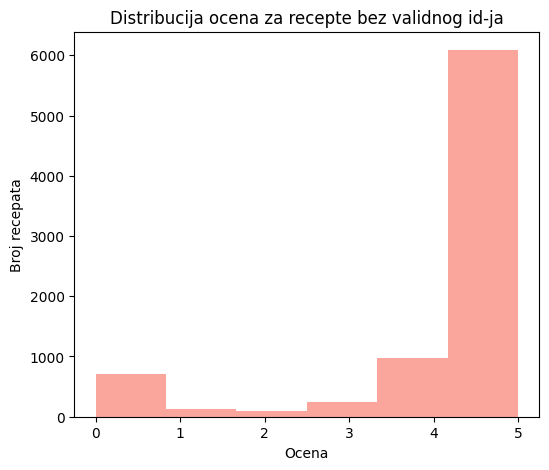

In [52]:
plt.figure(figsize=(6,5))
plt.hist(df_unmatched_ratings["rating"], bins=6, range=(0,5), color='salmon', alpha=0.7)
plt.xlabel("Ocena")
plt.ylabel("Broj recepata")
plt.title("Distribucija ocena za recepte bez validnog id-ja")
plt.show()

In [53]:
df_unmatched_ratings.to_csv("missing_ratings.csv", index=False)
df_interactions = df_interactions[df_interactions["recipe_id"].isin(df_recipes["id"])]

Uklonjene su sve ocene recepata čiji id-jevi se ne nalaze u tabeli recepata.

In [54]:
df_interactions["recipe_id"].is_unique

False

Jedan red po recenziji, recepti koji imaju više recenzija imaju više redova

In [55]:
df_all_reviews = pd.merge(
    df_interactions,
    df_recipes,
    left_on="recipe_id",
    right_on="id",
    how="left"
)

df_all_reviews  = df_all_reviews.drop(columns="id")
df_all_reviews.head()

,user_id,recipe_id,date,rating,review,name,minutes,contributor_id,submitted,tags,...,ingredients,n_ingredients,n_tags,calories,fat,sugar,sodium,protein,saturated fat,carbohydrates
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,white bean green chile pepper soup,495,1533,2002-09-21,"['weeknight', 'time-to-make', 'course', 'main-...",...,"['great northern beans', 'yellow onion', 'dice...",9,180,204.8,5.0,9.0,26.0,24.0,2.0,10.0
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",white bean green chile pepper soup,495,1533,2002-09-21,"['weeknight', 'time-to-make', 'course', 'main-...",...,"['great northern beans', 'yellow onion', 'dice...",9,180,204.8,5.0,9.0,26.0,24.0,2.0,10.0
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,devilicious cookie cake delights,20,56824,2002-10-27,"['30-minutes-or-less', 'time-to-make', 'course...",...,"[""devil's food cake mix"", 'vegetable oil', 'eg...",4,603,132.3,11.0,39.0,5.0,4.0,11.0,5.0
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,baked potato toppings,10,64342,2004-02-25,"['15-minutes-or-less', 'time-to-make', 'course...",...,"['mayonnaise', 'salsa', 'cheddar cheese', 'ref...",13,178,2786.2,342.0,134.0,290.0,161.0,301.0,42.0
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",baked potato toppings,10,64342,2004-02-25,"['15-minutes-or-less', 'time-to-make', 'course...",...,"['mayonnaise', 'salsa', 'cheddar cheese', 'ref...",13,178,2786.2,342.0,134.0,290.0,161.0,301.0,42.0


Jedan red po receptu sa prosečnom ocenom

In [56]:
df_recipes = df_all_reviews.groupby(["recipe_id", "name", "description"]).agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "count")
).reset_index()

cols = ["calories", "fat", "sugar", "sodium", "protein", "saturated fat", "carbohydrates", "ingredients", "n_ingredients", "minutes", 
        "contributor_id", "submitted", "tags", "n_steps", "steps", "description"]
df_nutrition = df_all_reviews[["recipe_id"] + cols].drop_duplicates()
df_recipes = df_recipes.merge(
    df_nutrition,
    on="recipe_id",
    how="left"
)

df_recipes["avg_rating"] = df_recipes["avg_rating"].round(2)
df_recipes.head()


,recipe_id,name,description_x,avg_rating,num_ratings,calories,fat,sugar,sodium,protein,...,carbohydrates,ingredients,n_ingredients,minutes,contributor_id,submitted,tags,n_steps,steps,description_y
0,39,biryani,"delhi, india",3.00,1,1110.7,90.0,81.0,15.0,126.0,...,28.0,"['saffron', 'milk', 'hot green chili peppers',...",26,265,1567,1999-08-29,"['weeknight', 'time-to-make', 'course', 'main-...",17,['soak saffron in warm milk for 5 minutes and ...,"delhi, india"
1,40,best lemonade,this is from one of my first good house keepi...,4.33,9,311.1,0.0,308.0,0.0,0.0,...,27.0,"['sugar', 'lemons, rind of', 'fresh water', 'f...",6,35,1566,1999-09-05,"['60-minutes-or-less', 'time-to-make', 'course...",8,"['into a 1 quart jar with tight fitting lid , ...",this is from one of my first good house keepi...
2,43,best blackbottom pie,"sweet, chocolatey, yummy",1.00,1,437.9,29.0,170.0,11.0,13.0,...,19.0,"['graham cracker crumbs', 'sugar', 'butter', '...",15,140,34879,1999-08-21,"['weeknight', 'time-to-make', 'course', 'cuisi...",35,"['graham cracker crust: in small bowl , combin...","sweet, chocolatey, yummy"
3,45,buttermilk pie with gingersnap crumb crust,yum,2.67,3,228.0,10.0,98.0,11.0,8.0,...,12.0,"['sugar', 'margarine', 'egg', 'egg whites', 'f...",9,80,1580,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...",10,"['preheat oven to 350f', 'make pie crust , usi...",yum
4,46,a jad cucumber pickle,it is a traditional accompaniment to snacks su...,5.00,2,4.3,0.0,0.0,0.0,0.0,...,0.0,"['rice vinegar', 'thangkwa', 'hom daeng', 'nam...",6,25,1533,1999-08-11,"['30-minutes-or-less', 'time-to-make', 'course...",5,"['slice the cucumber in four lengthwise , then...",it is a traditional accompaniment to snacks su...


## One-Hot Encoding sastojaka

Sastojci se transformišu u binarne kolone pomoću MultiLabelBinarizer-a.
Koristimo sparse reprezentaciju radi efikasnosti.

In [57]:
df_recipes["ingredients"].describe()

count                229634
unique               228493
top       ['eggs', 'water']
freq                     10
Name: ingredients, dtype: object

In [58]:
df_recipes["ingredients_list"] = df_recipes["ingredients"].apply(ast.literal_eval)

In [59]:
mlb = MultiLabelBinarizer(sparse_output=True)
ingredients_encoded = mlb.fit_transform(df_recipes["ingredients_list"])

df_ingredients = pd.DataFrame.sparse.from_spmatrix(
    ingredients_encoded,
    columns=[f"ing_{c}" for c in mlb.classes_],
    index=df_recipes.index
)

df_recipes_all_ingredients = pd.concat([df_recipes, df_ingredients], axis=1)

In [60]:
df_recipes_all_ingredients = df_recipes_all_ingredients.drop(columns = ["ingredients", "ingredients_list"])
df_recipes_all_ingredients.head()

,recipe_id,name,description_x,avg_rating,num_ratings,calories,fat,sugar,sodium,protein,...,ing_zinfandel,ing_ziploc bag,ing_ziploc bags,ing_ziti pasta,ing_ziti rigati,ing_zoom quick hot cereal,ing_zucchini,ing_zucchini with italian-style tomato sauce,ing_zwieback toast,ing_zwieback toast crumbs
0,39,biryani,"delhi, india",3.00,1,1110.7,90.0,81.0,15.0,126.0,...,0,0,0,0,0,0,0,0,0,0
1,40,best lemonade,this is from one of my first good house keepi...,4.33,9,311.1,0.0,308.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,43,best blackbottom pie,"sweet, chocolatey, yummy",1.00,1,437.9,29.0,170.0,11.0,13.0,...,0,0,0,0,0,0,0,0,0,0
3,45,buttermilk pie with gingersnap crumb crust,yum,2.67,3,228.0,10.0,98.0,11.0,8.0,...,0,0,0,0,0,0,0,0,0,0
4,46,a jad cucumber pickle,it is a traditional accompaniment to snacks su...,5.00,2,4.3,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
df_recipes.shape

(229634, 22)

In [62]:
df_ingredients.head()

,ing_1% fat buttermilk,ing_1% fat cottage cheese,ing_1% low-fat chocolate milk,ing_1% low-fat milk,ing_10 bean soup mix,ing_10 inch low-fat flour tortillas,"ing_10"" pie crust",ing_10% cream,ing_10-inch deep dish pie crust,ing_10-inch baked pie shells,...,ing_zinfandel,ing_ziploc bag,ing_ziploc bags,ing_ziti pasta,ing_ziti rigati,ing_zoom quick hot cereal,ing_zucchini,ing_zucchini with italian-style tomato sauce,ing_zwieback toast,ing_zwieback toast crumbs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
df_ingredients.shape

(229634, 14883)

In [64]:
ingredient_counts = np.array(df_ingredients.sum(axis=0)).flatten()

print("Minimalna frekvencija:", ingredient_counts.min())
print("Medijana:", np.median(ingredient_counts))
print("Prosečna frekvencija:", np.mean(ingredient_counts))
print("Maksimalna frekvencija:", ingredient_counts.max())

Minimalna frekvencija: 1
Medijana: 5.0
Prosečna frekvencija: 139.6545723308473
Maksimalna frekvencija: 85090


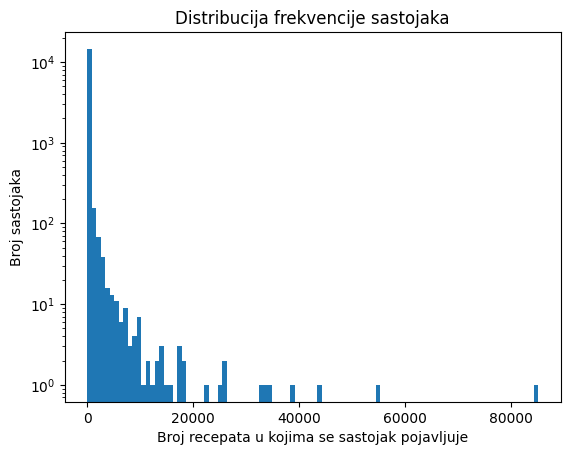

In [65]:
plt.hist(ingredient_counts, bins=100, log=True)
plt.xlabel("Broj recepata u kojima se sastojak pojavljuje")
plt.ylabel("Broj sastojaka")
plt.title("Distribucija frekvencije sastojaka")
plt.show()

Izbacujemo retke sastojke

In [66]:
print(df_ingredients.shape)

vt = VarianceThreshold(threshold=0.05)
vt.fit(df_ingredients)
df_ingredients = df_ingredients.loc[:, vt.get_support()]

print(df_ingredients.shape)

(229634, 14883)
(229634, 24)


In [67]:
df_recipes_reduced_ingredients = pd.concat([df_recipes, df_ingredients], axis=1)
df_recipes_reduced_ingredients.head()

,recipe_id,name,description_x,avg_rating,num_ratings,calories,fat,sugar,sodium,protein,...,ing_olive oil,ing_onion,ing_parmesan cheese,ing_pepper,ing_salt,ing_salt and pepper,ing_sugar,ing_vanilla,ing_vegetable oil,ing_water
0,39,biryani,"delhi, india",3.00,1,1110.7,90.0,81.0,15.0,126.0,...,0,1,0,0,1,0,0,0,1,0
1,40,best lemonade,this is from one of my first good house keepi...,4.33,9,311.1,0.0,308.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,43,best blackbottom pie,"sweet, chocolatey, yummy",1.00,1,437.9,29.0,170.0,11.0,13.0,...,0,0,0,0,1,0,1,0,0,1
3,45,buttermilk pie with gingersnap crumb crust,yum,2.67,3,228.0,10.0,98.0,11.0,8.0,...,0,0,0,0,1,0,1,0,0,0
4,46,a jad cucumber pickle,it is a traditional accompaniment to snacks su...,5.00,2,4.3,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
print(df_recipes_all_ingredients.shape)
print(df_recipes_reduced_ingredients.shape)
print(df_all_reviews.shape)

(229634, 14903)
(229634, 46)
(1124141, 23)


Podatke o receptima delimo na dva skupa radi lakše klasifikacije/klasterovanja

In [69]:
import pickle
with open("df_recipes_reduced_ingredients.pkl", "wb") as f:
    pickle.dump(df_recipes_reduced_ingredients, f)
with open("df_all_reviews.pkl", "wb") as f:
    pickle.dump(df_all_reviews, f)